In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
df = pd.read_csv('../data/sales_data.csv')
print(df.shape)
print(df.head())

(9800, 18)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID 

In [6]:
print(df.dtypes)
print(df.isnull().sum())

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')

print(df[['Order Date', 'Ship Date', 'Year', 'Month', 'Month Name']].head())

  Order Date  Ship Date  Year  Month Month Name
0 2017-11-08 2017-11-11  2017     11   November
1 2017-11-08 2017-11-11  2017     11   November
2 2017-06-12 2017-06-16  2017      6       June
3 2016-10-11 2016-10-18  2016     10    October
4 2016-10-11 2016-10-18  2016     10    October


In [9]:
monthly_sales = df.groupby(['Year', 'Month', 'Month Name'])['Sales'].sum().reset_index()
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])
print(monthly_sales)

    Year  Month Month Name        Sales
0   2015      1    January   14205.7070
1   2015      2   February    4519.8920
2   2015      3      March   55205.7970
3   2015      4      April   27906.8550
4   2015      5        May   23644.3030
5   2015      6       June   34322.9356
6   2015      7       July   33781.5430
7   2015      8     August   27117.5365
8   2015      9  September   81623.5268
9   2015     10    October   31453.3930
10  2015     11   November   77907.6607
11  2015     12   December   68167.0585
12  2016      1    January   18066.9576
13  2016      2   February   11951.4110
14  2016      3      March   32339.3184
15  2016      4      April   34154.4685
16  2016      5        May   29959.5305
17  2016      6       June   23599.3740
18  2016      7       July   28608.2590
19  2016      8     August   36818.3422
20  2016      9  September   63133.6060
21  2016     10    October   31011.7375
22  2016     11   November   75249.3995
23  2016     12   December   74543.6012


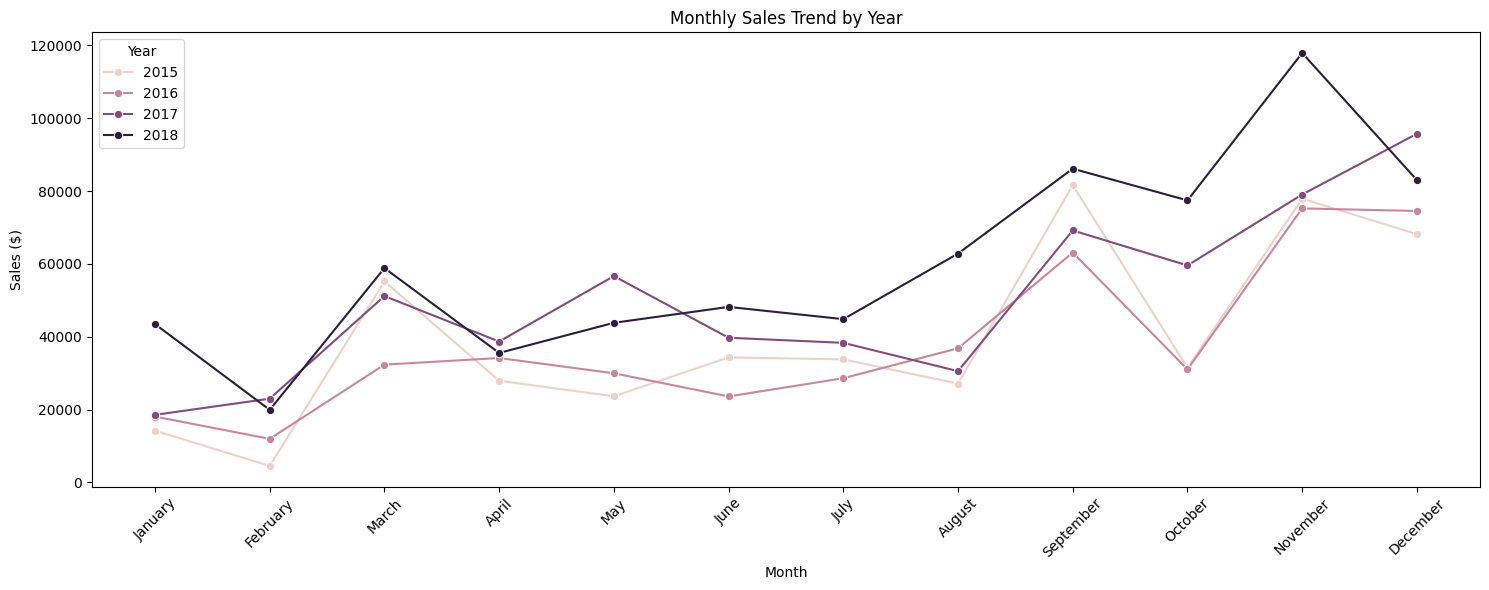

In [10]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sales, x='Month Name', y='Sales', hue='Year', marker='o')
plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('../dashboard/monthly_sales_trend.png')
plt.show()

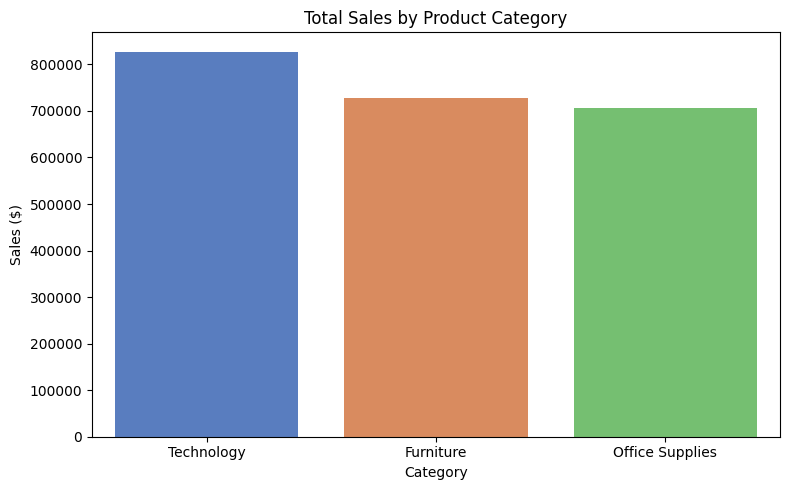

In [11]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values('Sales', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x='Category', y='Sales', palette='muted')
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('../dashboard/sales_by_category.png')
plt.show()

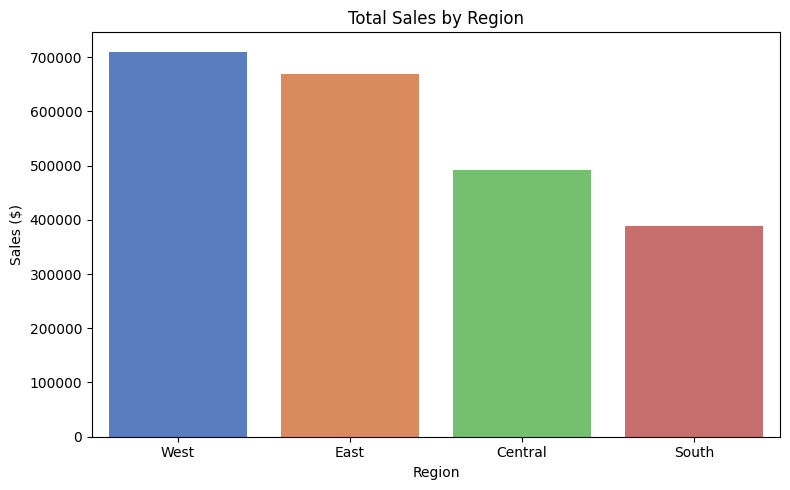

In [12]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales = region_sales.sort_values('Sales', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='muted')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('../dashboard/sales_by_region.png')
plt.show()

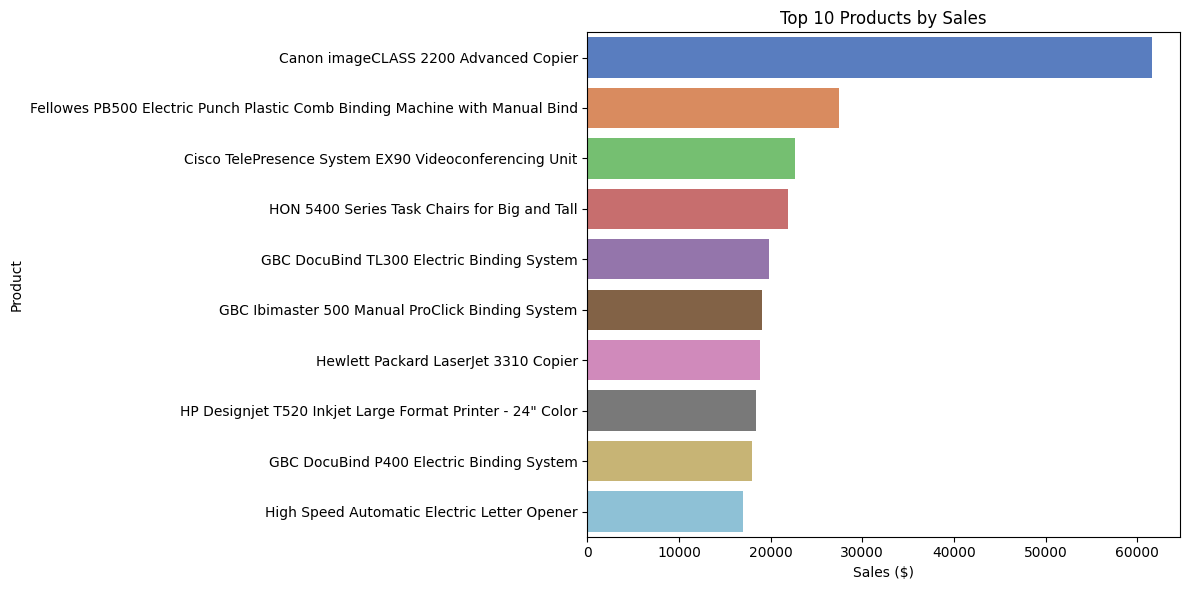

In [13]:
product_sales = df.groupby('Product Name')['Sales'].sum().reset_index()
product_sales = product_sales.sort_values('Sales', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=product_sales, x='Sales', y='Product Name', palette='muted')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('../dashboard/top10_products.png')
plt.show()

In [14]:
print("""
KEY FINDINGS — RETAIL SALES ANALYSIS
======================================

1. SALES TREND
   - Revenue has grown consistently from 2015 to 2018
   - September and November are peak months every year
   - February is consistently the weakest month

2. CATEGORY PERFORMANCE
   - Technology leads with ~$830,000 in total sales
   - Furniture and Office Supplies are close at ~$700,000 each

3. REGIONAL PERFORMANCE
   - West and East are the strongest regions
   - South is significantly underperforming at ~$390,000
   - The gap between West and South is ~$320,000

4. TOP PRODUCTS
   - Canon imageCLASS 2200 Copier is the standout product at ~$61,000
   - 7 of the top 10 products are office/technology equipment
""")


KEY FINDINGS — RETAIL SALES ANALYSIS

1. SALES TREND
   - Revenue has grown consistently from 2015 to 2018
   - September and November are peak months every year
   - February is consistently the weakest month

2. CATEGORY PERFORMANCE
   - Technology leads with ~$830,000 in total sales
   - Furniture and Office Supplies are close at ~$700,000 each

3. REGIONAL PERFORMANCE
   - West and East are the strongest regions
   - South is significantly underperforming at ~$390,000
   - The gap between West and South is ~$320,000

4. TOP PRODUCTS
   - Canon imageCLASS 2200 Copier is the standout product at ~$61,000
   - 7 of the top 10 products are office/technology equipment

